# Customer Churn Prediction 
**Project:** Tabular Machine Learning   
**Objective:** Load and explore the synthetic customer churn dataset to prepare for predictive modeling.

## Introduction
Customer churn is when a customer stops using a company's service.  
Predicting churn helps companies take action to retain customers, which is critical in industries like telecom.  

In this notebook, we will:  
1. Load the synthetic customer churn dataset  
2. Explore the data (EDA)  
3. Prepare insights for preprocessing and modeling

## Dataset Description
- **Rows:** 100k customers  
- **Columns:** 9 features + 1 target column `Churn`  
- **Feature types:** Numerical and categorical  
- **Target:** `Churn` (Yes/No)  

**Important features include:**  
- `tenure` — months with the company  
- `Contract` — type of contract (Month-to-month, One year, Two year)  
- `PaymentMethod` — method of payment  
- `TotalCharges` — total customer charges  

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset
We will load the dataset from the `data/` folder.  

In [2]:
# Path to local CSV
data_path = os.path.join("..", "data", "synthetic_customer_churn_100k.csv")

# Load dataset
df = pd.read_csv(data_path)

# Quick check
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100000, 9)


,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


## Exploratory Data Analysis (EDA)
EDA helps us understand the dataset before building models.  

We will:
- Check target variable distribution
- Analyze categorical and numerical features
- Visualize feature distributions
- Detect missing values or anomalies

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  str    
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  str    
 6   PaymentMethod   100000 non-null  str    
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 6.9 MB


,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


## Target Variable Distribution

In [4]:
# Target variable: 'Churn'
print("Target distribution:")
print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Target distribution:
Churn
No     66856
Yes    33144
Name: count, dtype: int64

Percentage:
Churn
No     66.856
Yes    33.144
Name: proportion, dtype: float64


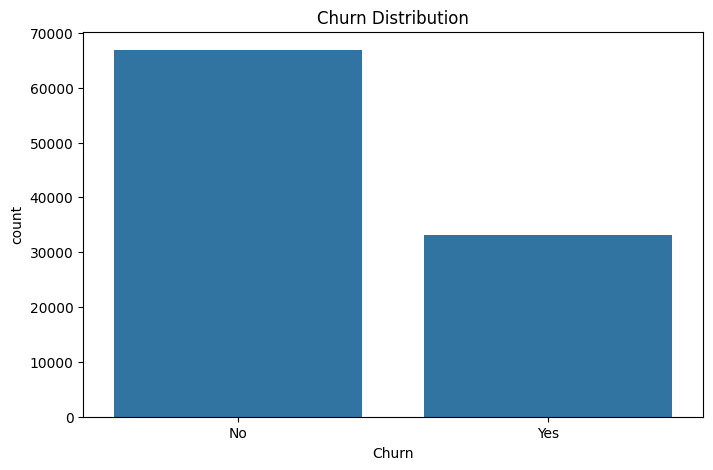

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.show()

In [6]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
CustomerID          int64
Age                 int64
Gender                str
Tenure              int64
MonthlyCharges    float64
Contract              str
PaymentMethod         str
TotalCharges      float64
Churn                 str
dtype: object

Missing Values:
CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64


## Separate Categorical & Numerical Features

In [12]:
# Select categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = numerical_cols.drop('CustomerID')

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: Index(['Gender', 'Contract', 'PaymentMethod', 'Churn'], dtype='str')
Numerical columns: Index(['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


C:\Users\khaou\AppData\Local\Temp\ipykernel_14024\2366884512.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## Categorical Feature Analysis


Column: Gender
Gender
Female    48256
Male      47787
Other      3957
Name: count, dtype: int64


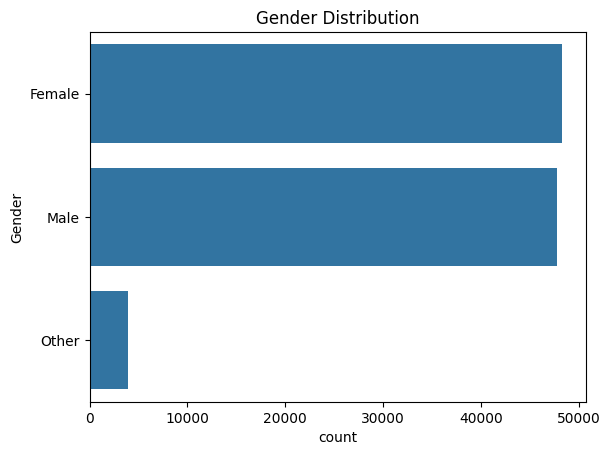


Column: Contract
Contract
Month-to-month    54915
One year          25261
Two year          19824
Name: count, dtype: int64


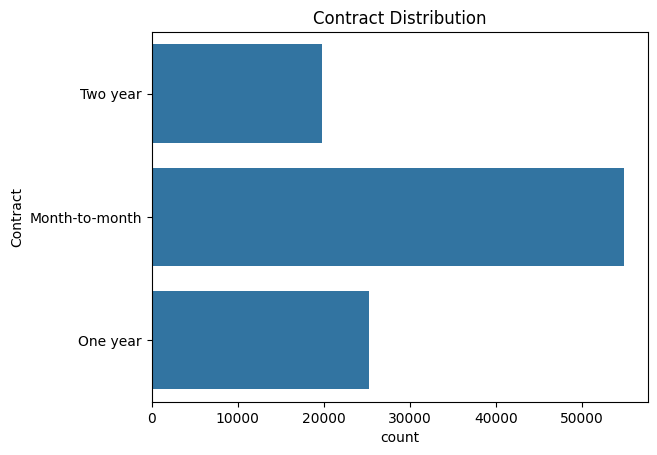


Column: PaymentMethod
PaymentMethod
Electronic check    34892
Mailed check        25221
Credit card         20032
Bank transfer       19855
Name: count, dtype: int64


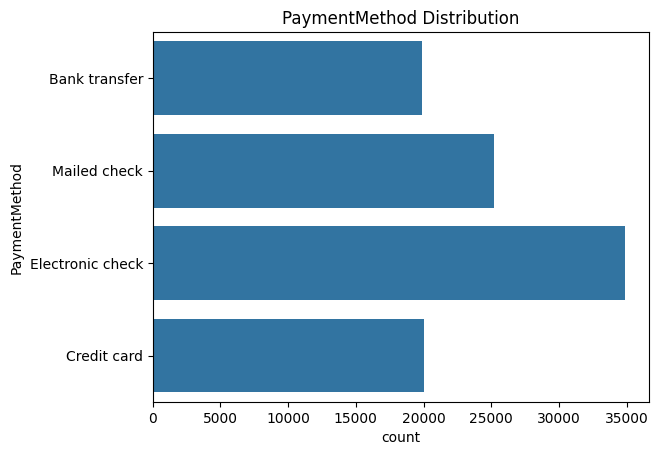


Column: Churn
Churn
No     66856
Yes    33144
Name: count, dtype: int64


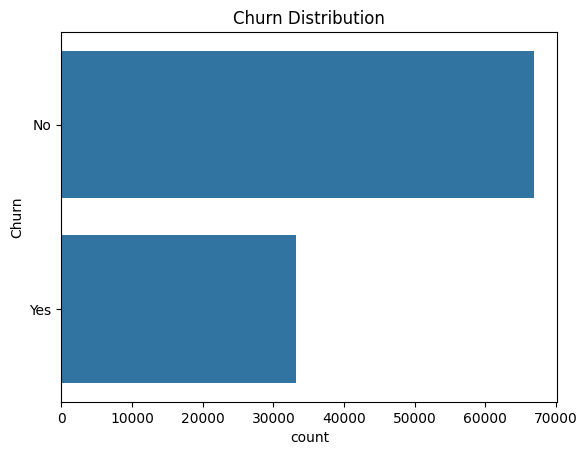

In [13]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    sns.countplot(y=col, data=df)
    plt.title(f"{col} Distribution")
    plt.show()

In [14]:
df[numerical_cols].describe()

,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,49.027240,36.527090,79.974933,2926.140256
std,18.177862,20.789552,40.491961,2388.163672
min,18.000000,1.000000,10.000000,-118.430000
25%,33.000000,18.000000,44.720000,963.667500
50%,49.000000,37.000000,80.000000,2268.060000
75%,65.000000,54.000000,115.050000,4394.327500
max,80.000000,72.000000,150.000000,10831.460000


## Correlation Between Numerical Features

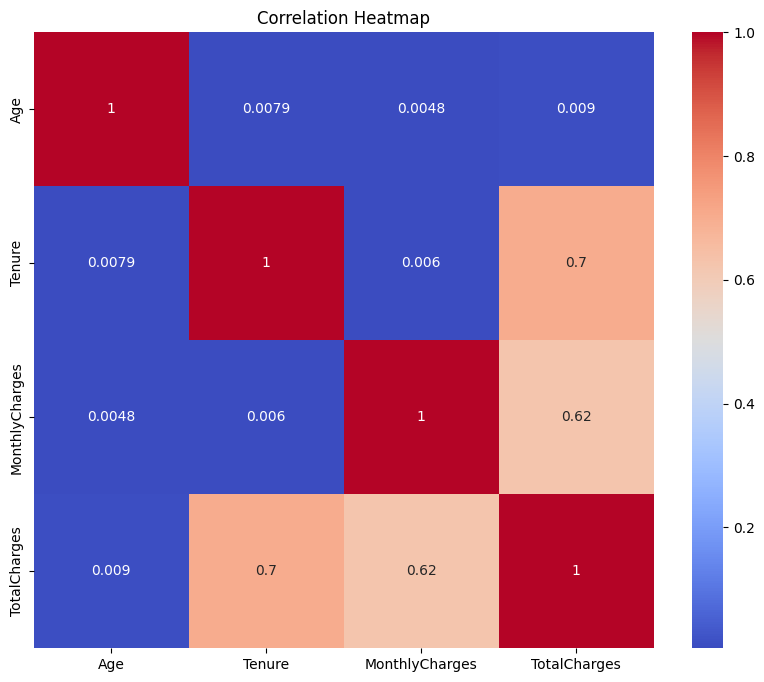

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Initial Observations / Insights

1. The target variable `Churn` is imbalanced (~33% Yes, ~67% No).  
2. Month-to-month contract customers have a higher churn rate.  
3. `tenure` and `TotalCharges` are strongly correlated.  
4. Several categorical features (PaymentMethod, InternetService, Contract) may influence churn.  

These insights will guide preprocessing and feature engineering in the next steps.

## Next Steps

1. **Data Preprocessing**  
   - Handle missing values  
   - Encode categorical variables  
   - Scale numerical variables  

2. **Modeling**  
   - Start with baseline models (Logistic Regression, Decision Tree)  
   - Evaluate performance using accuracy, F1-score, ROC-AUC  

3. **Advanced Models & Tuning**  
   - Gradient Boosting (XGBoost, LightGBM)  
   - Hyperparameter tuning with Optuna  
   - Feature importance and explainability (SHAP)